Este notebook documenta el flujo aplicado al dataset de activos de red.
El objetivo es generar un EDA completo, proponer ingeniería de características y dejar el dataset listo para entrenar un modelo DL enfocado en la métrica UITI.


## Flujo  propuesto
1. Preparar dependencias e importar librerías clave.
2. Cargar el dataset exacto mediante tu snippet kagglehub y validar su forma.
3. Ejecutar un EDA guiado (estructura, nulos, distribuciones, correlaciones, frecuencia de categorías).
4. Diseñar ingeniería de características útil para UITI y activos eléctricos.
5. Construir el pipeline de preprocesamiento y los conjuntos `train/valid` listos para DL.
6. Crear utilidades de `tf.data` y la plantilla de red neuronal para acelerar el entrenamiento NFL.


In [1]:
# -----------------------------------------------------------
# Configuración general del entorno: warnings, librerías y estilo gráfico
# -----------------------------------------------------------
# %pip install --quiet kagglehub[pandas-datasets] pandas numpy matplotlib seaborn plotly scikit-learn tensorflow

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path
from typing import List, Sequence

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler

try:
    import tensorflow as tf
except ImportError:
    tf = None
    print('TensorFlow no está instalado; instala tensorflow si deseas ejecutar la parte DL.')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)


In [2]:
# -----------------------------------------------------------
# Descarga oficial del dataset usando tu snippet kagglehub (mantener estilo)
# -----------------------------------------------------------
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "dataset_modificado.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "cristiancamiloo/powergrid-assets-ml-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

# Variables globales del flujo NFL
TARGET_COL = 'UITI'
df_original = df.copy()
print(f'Dataset con {df.shape[0]:,} filas y {df.shape[1]:,} columnas')


a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\work\prjAdvances\ipykernel_11572\2856973134.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(
a:\wnOs\LR\machineLearningTheoryEnv\TAM\devEnv\MLT_LR\PYDevEnv\lib\site-packages\kagglehub\pandas_datasets.py:91: DtypeWarning: Columns (20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


First 5 records:    Unnamed: 0 CODIGO TIPO             FECHA  DURACION    UITI  COD_CAUSA  \
0           0  28648  3RG  11/08/2024 20:45      0.18  398.00         22   
1           1  28648  3RG  18/11/2024 14:43      0.10  120.75         12   
2           2  28648  3RG  18/11/2024 14:43      0.77  812.06         12   
3           3  28648  3RG  18/11/2024 15:27      0.03   37.58         12   
4           4  28648  3RG  18/11/2024 15:30      0.06  150.36         12   

   NFASES  NEUTRO  LONGITUD  ...   Y2 FECHA_OPERACION TIPO_TAXONOMIA CLASE  \
0       3       1     57.62  ... -7.8            1995  Troncal_linea     T   
1       3       1     57.62  ... -7.8            1995  Troncal_linea     T   
2       3       1     57.62  ... -7.8            1995  Troncal_linea     T   
3       3       1     57.62  ... -7.8            1995  Troncal_linea     T   
4       3       1     57.62  ... -7.8            1995  Troncal_linea     T   

  ALTURA  CANTIDAD_TIERRA  LONG_CRUCETA  TRAFO VEGETACION

In [3]:
# -----------------------------------------------------------
# Muestreos rápidos para validar consistencia antes de la EDA
# -----------------------------------------------------------
with pd.option_context('display.max_columns', None):
    display(df.head(3))
    display(df.tail(3))
    display(df.sample(min(5, len(df)), random_state=42))


,Unnamed: 0,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA
0,0,28648,3RG,11/08/2024 20:45,0.18,398.00,22,3,1,57.62,1/0,ACSR,DESNUDO,N,2,235.35,-7.8,1995,Troncal_linea,T,12,1,2.0,0,0,13212.66
1,1,28648,3RG,18/11/2024 14:43,0.10,120.75,12,3,1,57.62,1/0,ACSR,DESNUDO,N,2,235.35,-7.8,1995,Troncal_linea,T,12,1,2.0,0,0,13212.66
2,2,28648,3RG,18/11/2024 14:43,0.77,812.06,12,3,1,57.62,1/0,ACSR,DESNUDO,N,2,235.35,-7.8,1995,Troncal_linea,T,12,1,2.0,0,0,13212.66


,Unnamed: 0,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA
661808,661808,L0293008,3CFR,02/04/2025 5:12,6.46,1138.13,20,1,1,498.0,2,ACSR,DESNUDO,G,2,235.53,-6.03,2025,Ramal,V,12.0,1,3.0,1,0,0.0
661809,661809,L0293008,3CFR,22/08/2025 19:48,12.96,1283.81,20,1,1,498.0,2,ACSR,DESNUDO,G,2,235.53,-6.03,2025,Ramal,V,12.0,1,3.0,1,0,0.0
661810,661810,L0293008,3CFR,20/03/2025 15:24,1.55,271.25,23,1,1,498.0,2,ACSR,DESNUDO,G,2,235.53,-6.03,2025,Ramal,V,12.0,1,3.0,1,0,0.0


,Unnamed: 0,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA
454810,454810,51833,3IG,24/09/2024 19:30,0.04,30.85,4,3,1,52.0,2/0,ACSR,DESNUDO,G,2/0,233.46,-7.71,1980,Troncal_linea,T,12.0,0,2.3,1,0,19522.23
557227,557227,43471,3RG,08/08/2024 5:08,3.59,1134.37,4,3,1,25.1,2/0,ACSR,DESNUDO,0,2/0,236.70,-7.23,1995,Troncal_propuesta,H,12.0,1,3.0,0,0,33505.20
483890,483890,58789,2CC,05/12/2024 7:03,0.95,35.31,29,2,1,77.0,2,ACSR,DESNUDO,No encontrado,2,237.12,-6.72,2011,Ramal,T,12,0,-99.0,0,0,1706.11
549941,549941,46221,3CC,20/11/2024 18:18,0.54,53.00,23,3,1,264.1,2/0,ACSR,DESNUDO,N,2/0,236.40,-6.45,1968,Ramal,R,10,0,2.0,0,1,2306.00
324154,324154,L0250681,3RL,21/11/2024 16:04,0.01,17.69,28,2,1,28.0,2,ACSR,CUBIERTO,G,1/0,235.89,-5.76,2022,Troncal_ramal,V,12.0,0,0.4,1,0,282.15


In [4]:
# -----------------------------------------------------------
# Métricas cuantitativas básicas del dataset original
# -----------------------------------------------------------
overview = pd.DataFrame(
    {
        'metricas': ['total_filas', 'total_columnas', 'duplicados', 'memoria_MB'],
        'valor': [
            int(len(df)),
            int(df.shape[1]),
            int(df.duplicated().sum()),
            round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2),
        ],
    }
)
display(overview)


,metricas,valor
0,total_filas,661811.00
1,total_columnas,26.00
2,duplicados,0.00
3,memoria_MB,513.95


In [5]:
# -----------------------------------------------------------
# Reporte estructural: tipos, nulos y cardinalidad
# -----------------------------------------------------------
structure_report = pd.DataFrame(
    {
        'columna': df.columns,
        'tipo_python': df.dtypes.astype(str).values,
        'nulos': df.isna().sum().values,
        'pct_nulos': (df.isna().sum().values / len(df)),
        'cardinalidad': df.nunique(dropna=False).values,
    }
).sort_values(by='pct_nulos', ascending=False)

display(structure_report)


,columna,tipo_python,nulos,pct_nulos,cardinalidad
14,CALIBRE_NEUTRO,object,121261,0.183226,21
22,LONG_CRUCETA,float64,2959,0.004471,17
20,ALTURA,object,2677,0.004045,41
19,CLASE,object,2677,0.004045,14
18,TIPO_TAXONOMIA,object,76,0.000115,6
0,Unnamed: 0,int64,0,0.000000,661811
1,CODIGO,object,0,0.000000,40523
24,VEGETACION,int64,0,0.000000,2
23,TRAFO,int64,0,0.000000,2
21,CANTIDAD_TIERRA,object,0,0.000000,5


In [6]:
# -----------------------------------------------------------
# Clasificación de variables (numéricas, categóricas, fechas, ids)
# -----------------------------------------------------------
assert TARGET_COL in df.columns, f'La columna objetivo {TARGET_COL} no existe.'

numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col != TARGET_COL]
categorical_candidates = [col for col in df.select_dtypes(exclude=[np.number]).columns if col != TARGET_COL]


def detect_datetime_columns(dataframe: pd.DataFrame, candidates: List[str], min_coverage: float = 0.65):
    datetime_cols = []
    coverage_map = {}
    for col in candidates:
        parsed = pd.to_datetime(dataframe[col], errors='coerce', infer_datetime_format=True)
        coverage = parsed.notna().mean()
        coverage_map[col] = round(float(coverage), 3)
        if coverage >= min_coverage:
            datetime_cols.append(col)
    return datetime_cols, coverage_map


datetime_features, datetime_coverage = detect_datetime_columns(df, categorical_candidates)
categorical_features = [col for col in categorical_candidates if col not in datetime_features]

id_like_features = [
    col
    for col in df.columns
    if any(token in col.lower() for token in ['id', 'codigo', 'cod_', 'asset', 'equipo', 'point'])
]

feature_catalog = pd.DataFrame(
    {
        'grupo': ['target', 'numeric', 'categorical', 'datetime', 'id_like'],
        'total_columnas': [
            1,
            len(numeric_features),
            len(categorical_features),
            len(datetime_features),
            len(id_like_features),
        ],
        'ejemplos': [
            TARGET_COL,
            ', '.join(numeric_features[:5]) or '-',
            ', '.join(categorical_features[:5]) or '-',
            ', '.join(datetime_features[:5]) or '-',
            ', '.join(id_like_features[:5]) or '-',
        ],
    }
)

print('Cobertura detectada para columnas datetime:', datetime_coverage)
display(feature_catalog)


Cobertura detectada para columnas datetime: {'CODIGO': 0.01, 'TIPO': 0.0, 'FECHA': 0.422, 'CALIBRE_F': 0.0, 'MATERIAL_F': 0.0, 'AISLAMIENTO_F': 0.0, 'G_N': 0.0, 'CALIBRE_NEUTRO': 0.0, 'TIPO_TAXONOMIA': 0.0, 'CLASE': 0.0, 'ALTURA': 0.602, 'CANTIDAD_TIERRA': 0.604}


,grupo,total_columnas,ejemplos
0,target,1,UITI
1,numeric,13,"Unnamed: 0, DURACION, COD_CAUSA, NFASES, NEUTRO"
2,categorical,12,"CODIGO, TIPO, FECHA, CALIBRE_F, MATERIAL_F"
3,datetime,0,-
4,id_like,3,"CODIGO, COD_CAUSA, CANTIDAD_TIERRA"


In [7]:
# -----------------------------------------------------------
# Mapa de valores faltantes priorizando imputaciones
# -----------------------------------------------------------
missing_report = (
    df.isna()
    .sum()
    .to_frame(name='nulos')
    .assign(pct=lambda x: x['nulos'] / len(df))
    .sort_values(by='pct', ascending=False)
)
missing_report = missing_report[missing_report['nulos'] > 0]

if missing_report.empty:
    print('No se detectaron nulos.')
else:
    display(missing_report)
    px.bar(
        missing_report.reset_index().rename(columns={'index': 'columna'}),
        x='columna',
        y='pct',
        title='Porcentaje de valores faltantes',
    ).show()


,nulos,pct
CALIBRE_NEUTRO,121261,0.183226
LONG_CRUCETA,2959,0.004471
ALTURA,2677,0.004045
CLASE,2677,0.004045
TIPO_TAXONOMIA,76,0.000115


In [8]:
# -----------------------------------------------------------
# Estadísticas descriptivas para numericas + target
# -----------------------------------------------------------
if numeric_features:
    summary_numeric = df[numeric_features + [TARGET_COL]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
    display(summary_numeric)
else:
    print('No existan variables numéricas aparte de la meta.')


,count,mean,std,min,1%,25%,50%,75%,99%,max
Unnamed: 0,661811.0,330905.000000,191048.523839,0.000,6618.100,165452.500,330905.00,496357.50,655191.90,6.618100e+05
DURACION,661811.0,2.063781,7.001165,0.001,0.001,0.008,0.03,1.32,26.06,6.072000e+02
COD_CAUSA,661811.0,22.909710,18.118408,3.000,4.000,20.000,23.00,28.00,29.00,5.640000e+02
NFASES,661811.0,2.679339,0.602284,1.000,1.000,3.000,3.00,3.00,3.00,3.000000e+00
NEUTRO,661811.0,0.816683,0.386926,0.000,0.000,1.000,1.00,1.00,1.00,1.000000e+00
LONGITUD,661811.0,167.817255,192.379496,0.400,3.700,40.400,96.40,223.60,901.10,2.807400e+03
X2,661811.0,235.475234,1.064841,232.890,233.010,235.020,235.80,236.13,237.24,2.376300e+02
Y2,661811.0,-6.594664,0.680075,-8.370,-7.950,-7.200,-6.48,-6.06,-5.46,-5.400000e+00
FECHA_OPERACION,661811.0,1991.353111,17.223574,1950.000,1968.000,1980.000,1980.00,2009.00,2025.00,2.025000e+03
LONG_CRUCETA,658852.0,1.511115,9.309143,-99.000,0.000,2.000,2.50,3.00,6.00,9.000000e+00


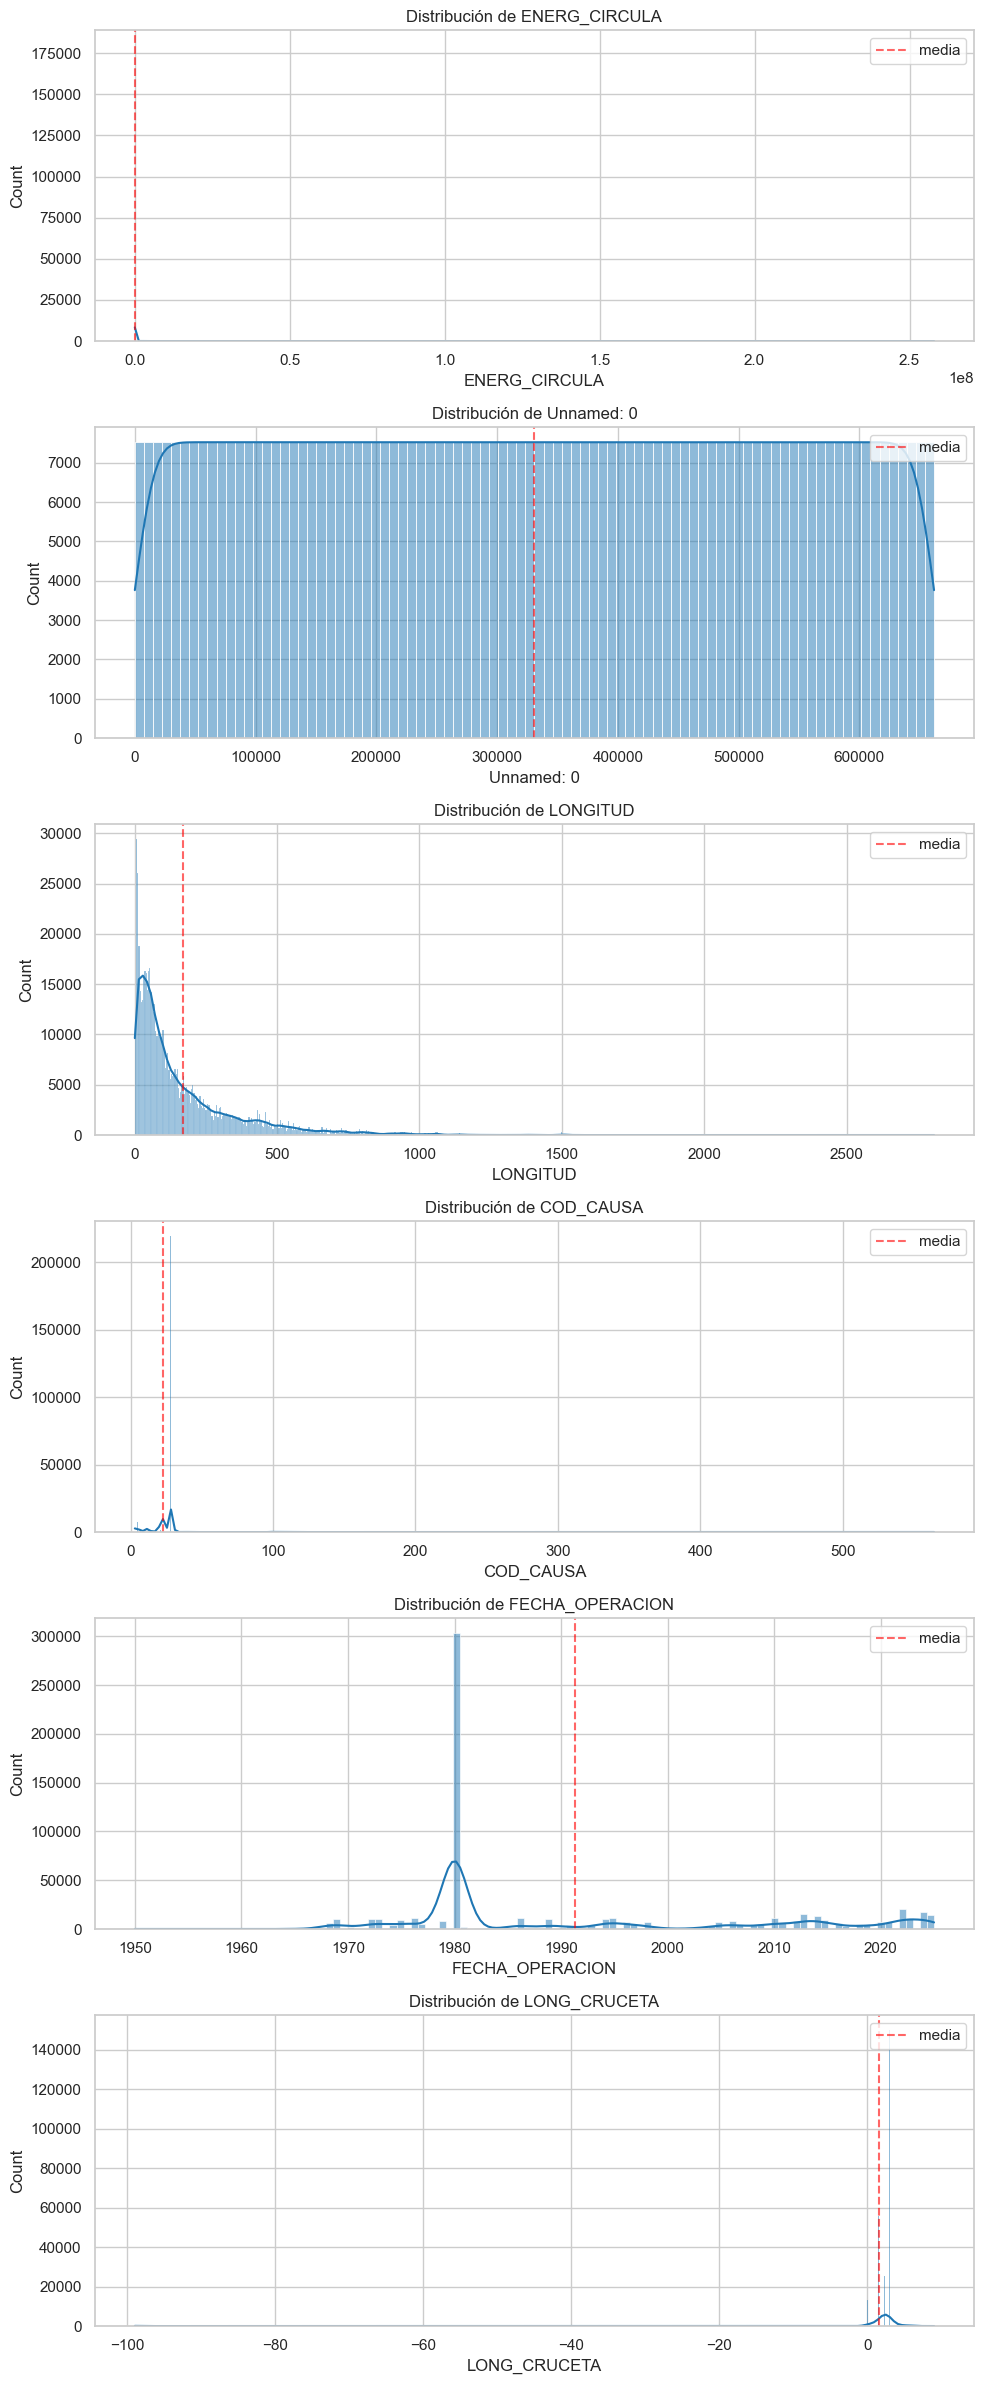

In [9]:
# -----------------------------------------------------------
# Distribuciones y sesgos de variables numéricas relevantes
# -----------------------------------------------------------
if numeric_features:
    selected_numeric = (
        df[numeric_features]
        .std()
        .sort_values(ascending=False)
        .head(min(6, len(numeric_features)))
        .index
        .tolist()
    )

    fig, axes = plt.subplots(len(selected_numeric), 1, figsize=(10, 4 * len(selected_numeric)))
    if len(selected_numeric) == 1:
        axes = [axes]
    for ax, col in zip(axes, selected_numeric):
        sns.histplot(df[col], kde=True, ax=ax, color='#1f77b4')
        ax.axvline(df[col].mean(), color='red', linestyle='--', alpha=0.6, label='media')
        ax.legend(loc='upper right')
        ax.set_title(f'Distribución de {col}')
    plt.tight_layout()
else:
    print('Sin variables numéricas para graficar.')


count    661811.000000
mean        362.239440
std        1298.476267
min           0.001000
1%            0.230000
25%           7.140000
50%          28.250000
75%         173.170000
99%        5808.340000
max       35887.980000
Name: UITI, dtype: float64

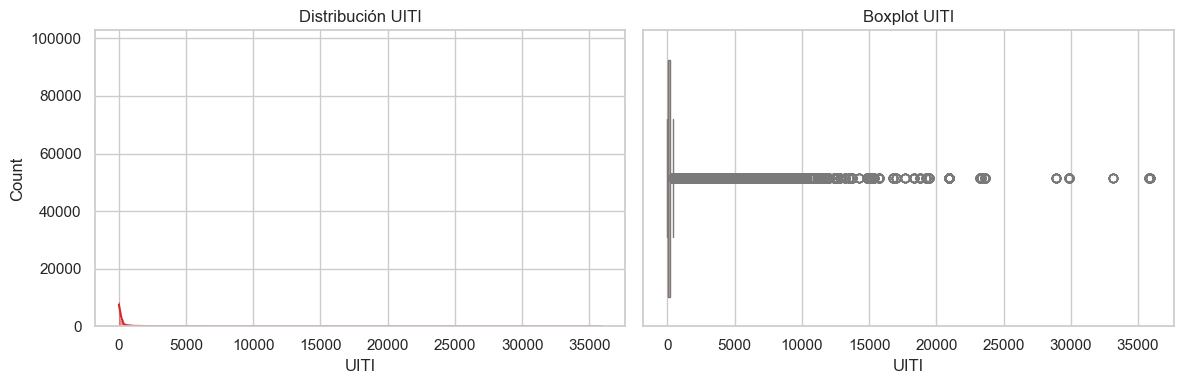

In [ ]:
# -----------------------------------------------------------
# Comportamiento y posibles outliers del objetivo UITI
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET_COL], kde=True, ax=axes[0], color='#d62728')
axes[0].set_title('Distribución UITI')
plt.xlim(0, df[TARGET_COL].quantile(0.99))
sns.boxplot(x=df[TARGET_COL], ax=axes[1], color='#ff9896')
axes[1].set_title('Boxplot UITI')
plt.tight_layout()

display(df[TARGET_COL].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))


In [12]:
# -----------------------------------------------------------
# Frecuencias top de variables categóricas para entender densidad operacional
# -----------------------------------------------------------
if categorical_features:
    for col in categorical_features:
        freq_df = (
            df[col]
            .value_counts(dropna=False)  # keep NaN if you need them
            .head(10)
            .reset_index(name='conteo')
            .rename(columns={'index': col})
        )
        fig = px.bar(freq_df, x=col, y='conteo', title=f'Distribución top 10 de {col}')
        fig.update_layout(xaxis={'categoryorder': 'total descending'})
        fig.show()
else:
    print('No se detectaron columnas categóricas.')


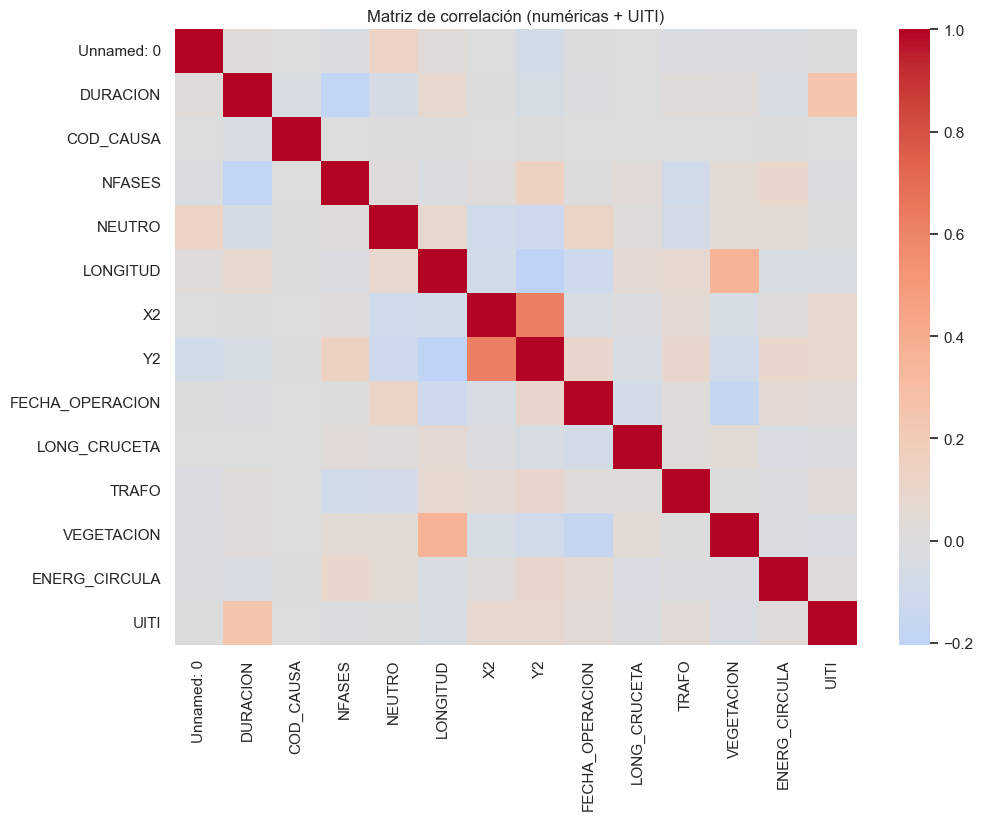

,corr_abs_uiti
DURACION,0.244427
X2,0.074738
Y2,0.073723
LONGITUD,0.038047
FECHA_OPERACION,0.036751


In [13]:
# -----------------------------------------------------------
# Correlaciones numéricas enfocadas en UITI
# -----------------------------------------------------------
if numeric_features:
    corr_matrix = df[numeric_features + [TARGET_COL]].corr()
    plt.figure(figsize=(11, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
    plt.title('Matriz de correlación (numéricas + UITI)')
    plt.show()

    target_corr = (
        corr_matrix[TARGET_COL]
        .drop(TARGET_COL)
        .abs()
        .sort_values(ascending=False)
        .head(min(5, len(numeric_features)))
    )
    display(target_corr.to_frame('corr_abs_uiti'))
else:
    print('No se puede calcular correlación sin variables numéricas.')


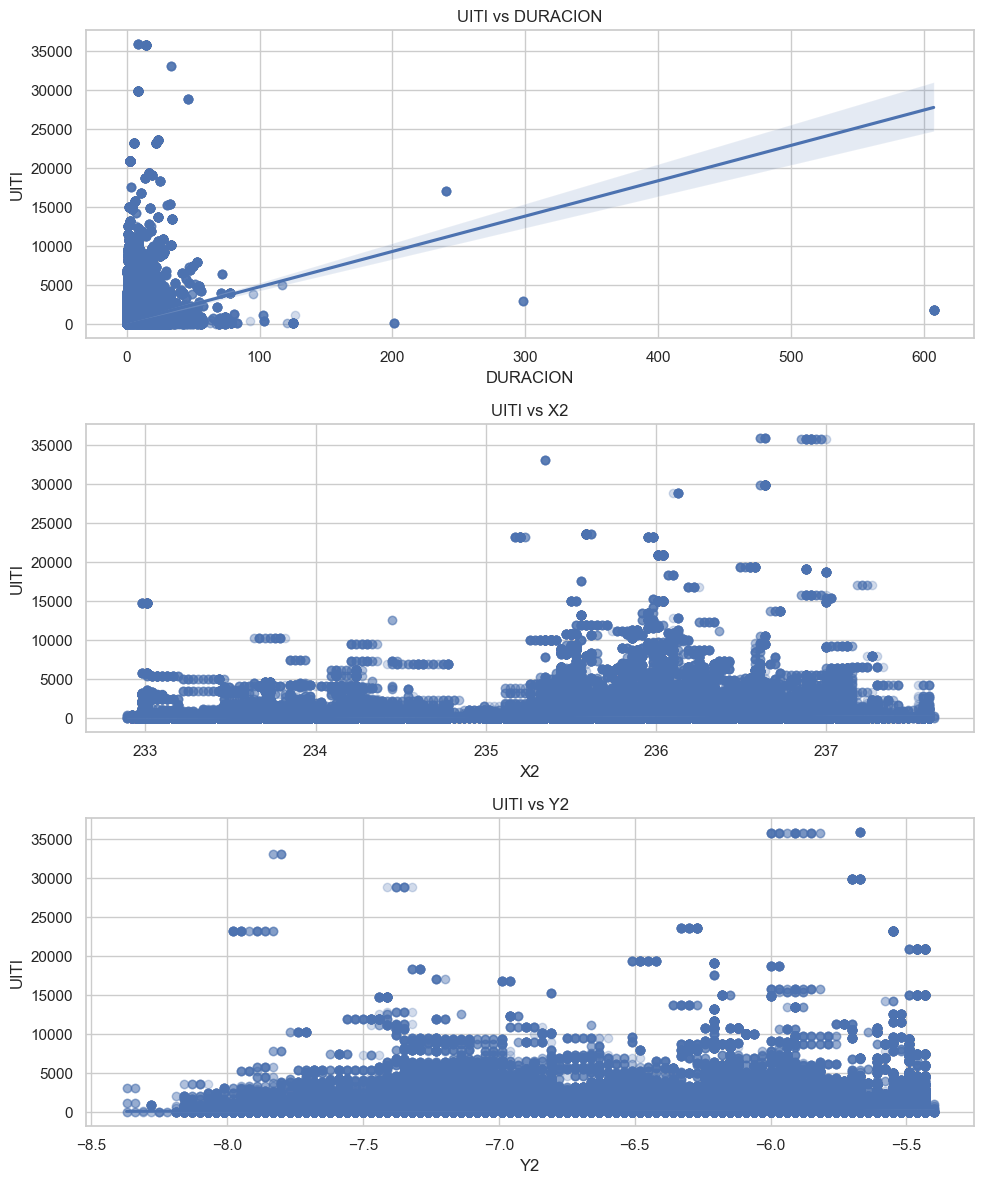

In [14]:
# -----------------------------------------------------------
# Relaciones bilaterales entre UITI y las features más correlacionadas
# -----------------------------------------------------------
if numeric_features:
    corr_matrix = df[numeric_features + [TARGET_COL]].corr()
    main_drivers = (
        corr_matrix[TARGET_COL]
        .drop(TARGET_COL)
        .abs()
        .sort_values(ascending=False)
        .head(min(3, len(numeric_features)))
        .index
        .tolist()
    )

    fig, axes = plt.subplots(len(main_drivers), 1, figsize=(10, 4 * len(main_drivers)))
    if len(main_drivers) == 1:
        axes = [axes]
    for ax, col in zip(axes, main_drivers):
        sns.regplot(x=df[col], y=df[TARGET_COL], ax=ax, scatter_kws={'alpha': 0.25})
        ax.set_title(f'UITI vs {col}')
    plt.tight_layout()
else:
    print('Sin variables numéricas para scatter plots.')


## Ingeniería  sobre el dataset
- Derivamos componentes temporales (año, mes, día, día de la semana) para cada fecha fiable.
- Transformamos magnitudes largas (duraciones/intensidades) con `log1p` + `zscore`.
- Añadimos frecuencias de aparición para códigos/ids/categorías.
- Colapsamos categorías raras bajo la etiqueta `OTROS_NFL` para estabilizar el one-hot.


In [15]:
# -----------------------------------------------------------
# Construcción del dataframe enriquecido con nuevas features
# -----------------------------------------------------------
df_fe = df.copy()
feature_notes = []

parsed_datetime_cols = []
for col in datetime_features:
    parsed = pd.to_datetime(df_fe[col], errors='coerce', infer_datetime_format=True)
    coverage = parsed.notna().mean()
    if coverage < 0.5:
        continue
    df_fe[col] = parsed
    df_fe[f'{col}_year'] = parsed.dt.year
    df_fe[f'{col}_month'] = parsed.dt.month
    df_fe[f'{col}_day'] = parsed.dt.day
    df_fe[f'{col}_dow'] = parsed.dt.dayofweek
    parsed_datetime_cols.append(col)
    feature_notes.extend([f'{col}_year', f'{col}_month', f'{col}_day', f'{col}_dow'])

possible_duration_cols = [col for col in df_fe.columns if 'dur' in col.lower() or 'tiempo' in col.lower()]
for col in possible_duration_cols:
    df_fe[col] = pd.to_numeric(df_fe[col], errors='coerce')
    df_fe[f'{col}_log1p'] = np.log1p(df_fe[col].clip(lower=0))
    df_fe[f'{col}_zscore'] = (df_fe[col] - df_fe[col].mean()) / (df_fe[col].std() or 1)
    feature_notes.extend([f'{col}_log1p', f'{col}_zscore'])

cat_for_freq = sorted(set(categorical_features + [c for c in id_like_features if c in df.columns]))
for col in cat_for_freq:
    freq_series = df_fe[col].value_counts(dropna=False)
    df_fe[f'{col}_freq'] = df_fe[col].map(freq_series).fillna(0)
    feature_notes.append(f'{col}_freq')


def collapse_rare_categories(series: pd.Series, min_freq: float = 0.01) -> pd.Series:
    freq = series.value_counts(normalize=True, dropna=False)
    rare_labels = freq[freq < min_freq].index
    return series.replace(rare_labels, 'OTROS_NFL')

for col in categorical_features:
    df_fe[col] = collapse_rare_categories(df_fe[col].astype('string'))

numeric_features_enhanced = [col for col in df_fe.select_dtypes(include=[np.number]).columns if col != TARGET_COL]
categorical_features_clean = [col for col in df_fe.select_dtypes(exclude=[np.number]).columns if col != TARGET_COL]

print(f'Columnas originales: {df.shape[1]} -> tras ingeniería: {df_fe.shape[1]}')
print('Nuevas columnas clave:', feature_notes[:15], '...')


MemoryError: Unable to allocate 5.05 MiB for an array with shape (661811,) and data type object

In [ ]:
# -----------------------------------------------------------
# Pipeline de preprocesamiento + splits listos para DL
# -----------------------------------------------------------
numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=False)),
        ('scaler', StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False)),
    ]
)

transformers = []
if numeric_features_enhanced:
    transformers.append(('numeric', numeric_pipeline, numeric_features_enhanced))
if categorical_features_clean:
    transformers.append(('categorical', categorical_pipeline, categorical_features_clean))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

X = df_fe.drop(columns=[TARGET_COL])
y = df_fe[TARGET_COL]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

preprocessor.fit(X_train)
X_train_ready = preprocessor.transform(X_train)
X_valid_ready = preprocessor.transform(X_valid)

if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names_out = preprocessor.get_feature_names_out().tolist()
else:
    feature_names_out = numeric_features_enhanced
    if categorical_features_clean:
        encoder = preprocessor.named_transformers_['categorical'].named_steps['encoder']
        feature_names_out += encoder.get_feature_names_out(categorical_features_clean).tolist()

print(f'X_train listo: {X_train_ready.shape} | X_valid listo: {X_valid_ready.shape}')
print(f'Número total de features tras preprocesar: {len(feature_names_out)}')


In [ ]:
# -----------------------------------------------------------
# Conversión a tf.data datasets para acelerar el entrenamiento NFL
# -----------------------------------------------------------
import numpy.typing as npt

def build_tf_dataset(features: npt.NDArray, labels: pd.Series, batch_size: int = 256, shuffle: bool = True):
    if tf is None:
        raise ImportError('TensorFlow no está disponible en este entorno.')
    dataset = tf.data.Dataset.from_tensor_slices((features.astype('float32'), labels.to_numpy(dtype='float32')))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(features), reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

if tf is not None:
    train_ds = build_tf_dataset(X_train_ready, y_train)
    valid_ds = build_tf_dataset(X_valid_ready, y_valid, shuffle=False)
    print(train_ds)
    print(valid_ds)
else:
    print('Instala tensorflow para materializar tf.data datasets.')


In [ ]:
# -----------------------------------------------------------
# Plantilla base de red neuronal para UITI (ajusta hiperparámetros NFL)
# -----------------------------------------------------------
from typing import Sequence

def build_nfl_regressor(input_dim: int, hidden_units: Sequence[int] = (256, 128, 64), dropout_rate: float = 0.15):
    if tf is None:
        raise ImportError('TensorFlow no está instalado; no se puede construir la red.')

    inputs = tf.keras.Input(shape=(input_dim,), name='feature_vector')
    x = inputs
    for units in hidden_units:
        x = tf.keras.layers.Dense(units, activation='relu')(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(1, activation='linear', name='uiti')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='nfl_uiti_model')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
    )
    return model

if tf is not None and 'X_train_ready' in globals():
    nfl_model = build_nfl_regressor(X_train_ready.shape[1])
    nfl_model.summary()
else:
    print('Activa TensorFlow para instanciar y resumir el modelo NFL.')
